**Описовий аналіз даних - вивчення основних х-стик даних**
1. Збір даних
2. Перевірка правильності даних (пропуски)
3. Опис структури даних (features, data_types)
4. Вивчення основних характеристик (.describe() statistics)
5. Побудова графіків та візуалізація
6. Виявлення викидів та аномалій
7. Опис груп та підгруп
8. Формулювання висновків (trends, patterns)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
dataset = datasets.load_breast_cancer()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# вивід стовпців, типи і к-сть non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**Стандартизація даних до одного діапазону/шкали**
- деякі моделі чутливі до діапазону: knn
- faster convergence (GD algorithm)
- for L1 lasso/L2 ridge regularization (adding penalty to loss f(x))
- avoid exploiding gradient
- stabilization

In [6]:
# виведемо column 'target' (binary classification: 0 or 1)
dataset['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [7]:
# data_scale() - f(x) for standartization (scaler_type це тип масштабування)
def data_scale(data, scaler_type='minmax'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type == "minmax":
        scaler = MinMaxScaler() #[0,1] - (x-min(x)) / (max(x) - min(x))
    elif scaler_type == "std":
        scaler = StandardScaler() # mean=0, std=1
    elif scaler_type == 'norm':
        scaler = Normalizer() # scale each sample, so that vector=1
    else:
        print('Scaler type definition error')
        return None
    
    scaler.fit(data)
    res = scaler.transform(data)
    return res

data_scaled = data_scale(df, 'std')
df_scaled = pd.DataFrame(data_scaled, columns=df.columns)
df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [8]:
df_scaled.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-3.153111e-15,-6.568462e-15,-6.993039e-16,-8.553985e-16,6.081447e-15,-1.136369e-15,-2.997017e-16,1.023981e-15,-1.860648e-15,-1.504752e-15,...,-2.297713e-15,1.742016e-15,-1.198807e-15,6.118909e-16,-5.094929e-15,-2.122887e-15,6.118909e-16,-1.998011e-16,-2.422589e-15,2.497514e-15
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423e+00,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-6.421359e-01,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-3.411812e-01,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,3.575891e-01,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172e+00,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


In [9]:
# Сформуємо список назв стовпців
col_names = list(dataset.feature_names) 

# додаємо новий стовбець
col_names.append('cancer')
col_names

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'cancer']

In [10]:
# в новому datafram поєднуєм ознаки та цільову змінну
df_target = pd.DataFrame(dataset['target'], columns=['cancer'])
df_target

,cancer
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [11]:
# df_bc - breast cancer dataframe, який містить стандартизовані ознаки та цільову змінну
df_bc = pd.concat([df_scaled, df_target], axis=1) # axis=1 - поєднуємо по стовпцях, axis=0 - поєднуємо по рядках
df_bc.columns = col_names # присвоюємо нові назви стовпців
df_bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,cancer
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,0
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,0
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,0


In [12]:
# перевіримо баланс класів
df_bc['cancer'].value_counts()

cancer
1    357
0    212
Name: count, dtype: int64

In [13]:
# виведемо назви стовпців атрибутом columns
df_bc.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'cancer'],
      dtype='object')

In [14]:
# створимо вибірку лише з даних ознак:  'mean radius', 'mean texture'
df_bc[['mean radius', 'mean texture']]

,mean radius,mean texture
0,1.097064,-2.073335
1,1.829821,-0.353632
2,1.579888,0.456187
3,-0.768909,0.253732
4,1.750297,-1.151816
...,...,...
564,2.110995,0.721473
565,1.704854,2.085134
566,0.702284,2.045574
567,1.838341,2.336457


### Графіки

<Axes: xlabel='cancer', ylabel='count'>

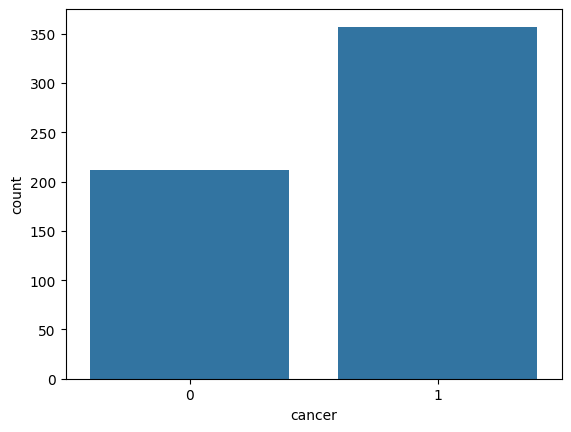

In [15]:
# Графік розподілу семплів за класом
sns.countplot(data=df_bc, x='cancer')

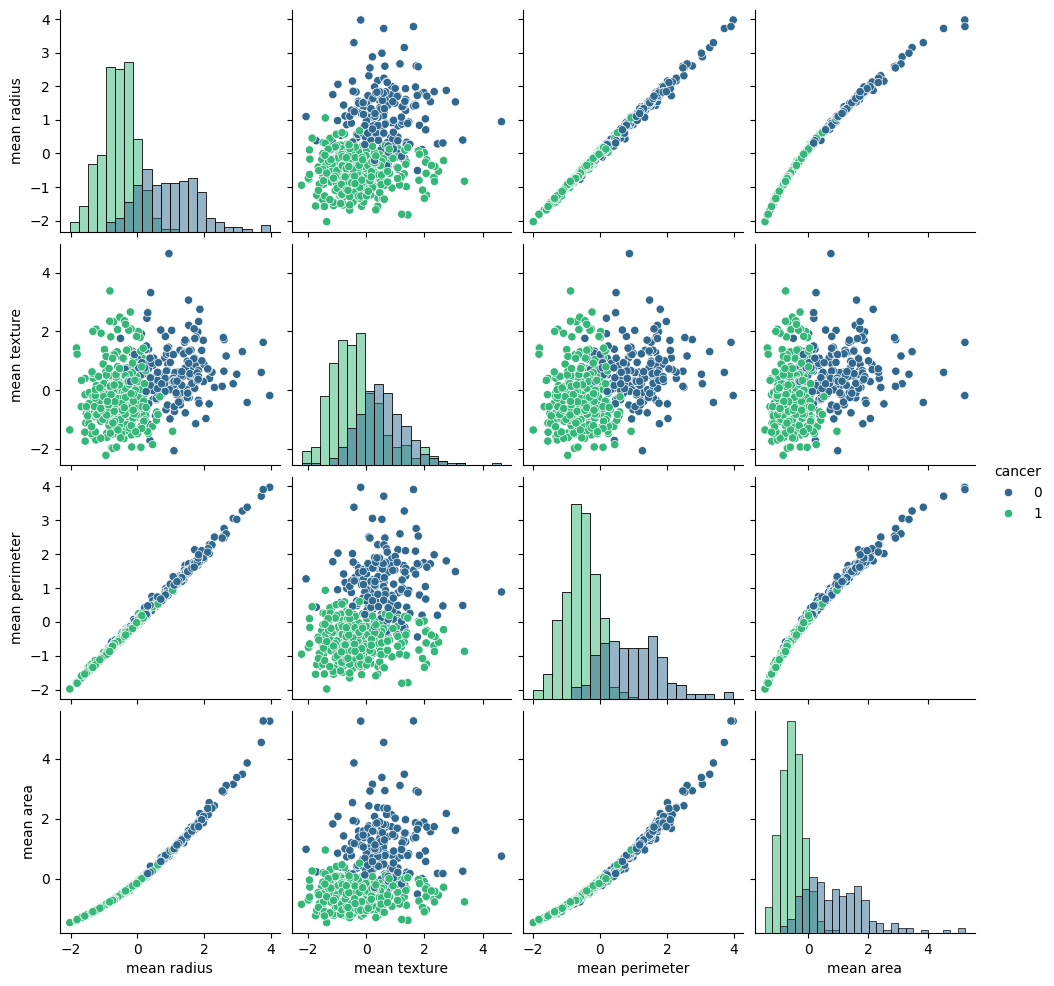

In [16]:
# scatter plot точкова діаграма за групами ознак: 'mean radius', 'mean texture', 'mean perimeter', 'mean area'
sns.pairplot(df_bc[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'cancer']], hue='cancer', palette='viridis', diag_kind='hist')

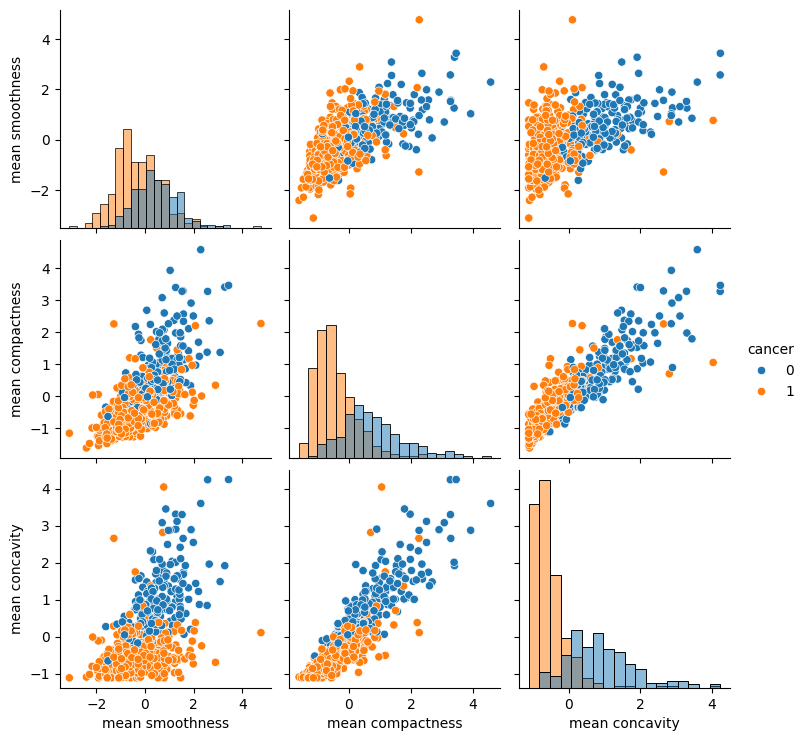

In [17]:
# scatter plot точкова діаграма за групами ознак: 'mean smoothness', 'mean compactness', 'mean concavity'
sns.pairplot(df_bc[['mean smoothness', 'mean compactness', 'mean concavity', 'cancer']], hue='cancer', palette='tab10', diag_kind='hist')

Розподіл даних для навчання (train_test_split)
- eval generalization
- avoid overfitting
- eval hyperparams, number of layers

In [18]:
# X - data, y-label
X, y = df_scaled, dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [19]:
from sklearn.linear_model import LogisticRegression
# classifier - це алгоритм, який навчається на даних і робить передбачення класу для нових даних
clf = LogisticRegression(random_state=0).fit(X_train,y_train) # random_state param для відтворюваності результатів

In [20]:
# передбачення класу для тестової вибірки
y_pred = clf.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1])

In [21]:
# передбачення ймовірності класу для тестової вибірки
clf.predict_proba(X_test)

array([[9.99999208e-01, 7.92066747e-07],
       [3.25767587e-06, 9.99996742e-01],
       [5.15345261e-05, 9.99948465e-01],
       [9.96968893e-01, 3.03110710e-03],
       [3.38382642e-04, 9.99661617e-01],
       [2.27349717e-04, 9.99772650e-01],
       [3.16738565e-05, 9.99968326e-01],
       [9.99999958e-01, 4.17266210e-08],
       [5.65604837e-04, 9.99434395e-01],
       [9.99939666e-01, 6.03336545e-05],
       [7.69295446e-08, 9.99999923e-01],
       [9.91562242e-01, 8.43775766e-03],
       [9.96642558e-01, 3.35744216e-03],
       [1.09550303e-03, 9.98904497e-01],
       [9.99999993e-01, 6.98265581e-09],
       [3.97927005e-02, 9.60207300e-01],
       [8.48464332e-03, 9.91515357e-01],
       [9.99998882e-01, 1.11805167e-06],
       [9.97988290e-01, 2.01171002e-03],
       [9.99971521e-01, 2.84792785e-05],
       [8.05656968e-04, 9.99194343e-01],
       [2.65059803e-05, 9.99973494e-01],
       [1.81396824e-05, 9.99981860e-01],
       [5.99279347e-04, 9.99400721e-01],
       [1.596133

**Confusion Matrix** - Оцінка точності моделі(к-сть правильних/неправильних класифікацій)

1. True Positive (TP): Кількість прикладів, які правильно були визначені як позитивні.
2. True Negative (TN): Кількість прикладів, які правильно були визначені як негативні.
3. False Positive (FP): Кількість прикладів, які були помилково визначені як позитивні (тип помилки I роду або False Alarm).
4. False Negative (FN): Кількість прикладів, які були помилково визначені як негативні (тип помилки II роду або Miss).

чутливість (recall)
достовірність (precision)

In [22]:
cm = confusion_matrix(np.asarray(y_test), np.asarray(y_pred))
cm

# ([TN, FP],
#  [FN, TP])

array([[42,  2],
       [ 0, 70]])

In [23]:
# вивід звіту про класифікацію
print(classification_report(np.asarray(y_test), np.asarray(y_pred)))
# f1 score - середнє між precision і recall. Чим вище f1 score, тим краща модель.
# weighted avg - середнє f1 score по класах, зважене на кількість семплів в кожному класі. Чим вище weighted avg, тим краща модель.
# support - кількість семплів в кожному класі.

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        44
           1       0.97      1.00      0.99        70

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**Бібліотека PyCaret** для автоматизації ML процесу(авто порівняння моделей, параметрів, вибір ознак, аномалій, дисбалансу клсів і тд)

In [24]:
# !pip install pycaret[full]
from pycaret.classification import *

In [25]:
# setup() аналізує датасет, робить preprocessing, env setup, train/test split
clf1 = setup(df_bc, target='cancer', session_id=555)

,Description,Value
0,Session id,555
1,Target,cancer
2,Target type,Binary
3,Original data shape,"(569, 31)"
4,Transformed data shape,"(569, 31)"
5,Transformed train set shape,"(398, 31)"
6,Transformed test set shape,"(171, 31)"
7,Numeric features,30
8,Preprocess,True
9,Imputation type,simple


In [ ]:
# Порівняння різних моделей
compare_models()
'''
AUC - Area Under the Receiver Operating Characteristic Curve, показує здатність моделі розрізняти класи.
Kappa - показує, наскільки добре модель класифікує дані, порівняно з випадковим вгадуванням.
MCC - Matthews Correlation Coefficient, показує якість класифікації, враховуючи TP, TN, FP, FN.
TT - Time taken - час, який знадобився для навчання моделі.
'''

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9849,0.9961,1.0000,0.9772,0.9883,0.9672,0.9683,0.5870
svm,SVM - Linear Kernel,0.9698,0.9886,0.9800,0.9736,0.9760,0.9350,0.9375,0.0070
et,Extra Trees Classifier,0.9649,0.9919,0.9840,0.9626,0.9725,0.9240,0.9269,0.0270
catboost,CatBoost Classifier,0.9649,0.9939,0.9840,0.9624,0.9723,0.9242,0.9272,1.1620
knn,K Neighbors Classifier,0.9648,0.9806,0.9880,0.9591,0.9727,0.9231,0.9262,0.0090
ada,Ada Boost Classifier,0.9623,0.9817,0.9800,0.9619,0.9704,0.9185,0.9205,0.0250
qda,Quadratic Discriminant Analysis,0.9599,0.9910,0.9640,0.9729,0.9678,0.9144,0.9167,0.0070
lda,Linear Discriminant Analysis,0.9597,0.9877,1.0000,0.9422,0.9696,0.9099,0.9158,0.0070
gbc,Gradient Boosting Classifier,0.9573,0.9894,0.9760,0.9573,0.9663,0.9081,0.9096,0.0660
ridge,Ridge Classifier,0.9572,0.9901,0.9960,0.9413,0.9674,0.9052,0.9102,0.0070


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=555, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9824561403508771

In [ ]:
'''
Точнiсть (Presicion) - відношення правильно класифікованих позитивних (True Positives) 
до загальної кількості прикладів, які модель визначила як позитивні (True Positives + False Positives).
'''



